# LiDAR pipeline

Full LAS-to-DEM workflow on an in-memory synthetic point cloud:

```text
LasPoints # constructed here; LAS file I/O is laspy-gated
 → classify_ground # Zhang 2003 morphological tophat
 → filter_classes({2}) # keep ground points
 → grid_lidar_points # IDW / TIN interpolation
 → detect_trees # variable-window local-maxima on a CHM
 → clip / merge # polygon clip + concatenate
```

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
from shapely.geometry import box

from digitalrivers.lidar import (
 LasPoints,
 classify_ground,
 clip,
 detect_trees,
 filter_classes,
 grid_lidar_points,
 merge,
)

# Synthetic cloud: 600 ground points sprinkled across a 20×20 m plot, plus four "trees" of
# varying height and one "building" cluster.
rng = np.random.default_rng(seed=2026)
n_ground = 600
ground_xy = rng.uniform(0, 20, size=(n_ground, 2))
ground_z = rng.normal(0, 0.05, size=n_ground)
ground_cls = np.full(n_ground, 2, dtype=np.uint8)

# Trees: 4 isolated canopy peaks.
tree_xy = np.array([[5, 5], [5.1, 5.05], [15, 5], [10, 15], [10.05, 15.05]])
tree_z = np.array([6.5, 6.1, 8.2, 4.0, 3.7])
tree_cls = np.full(5, 5, dtype=np.uint8)

# Building footprint cluster (flat roof).
build_xy = np.array([[15, 15], [15.5, 15], [15, 15.5], [15.5, 15.5]])
build_z = np.full(4, 3.0)
build_cls = np.full(4, 6, dtype=np.uint8)

xs = np.concatenate([ground_xy[:, 0], tree_xy[:, 0], build_xy[:, 0]])
ys = np.concatenate([ground_xy[:, 1], tree_xy[:, 1], build_xy[:, 1]])
zs = np.concatenate([ground_z, tree_z, build_z])
classification = np.concatenate([ground_cls, tree_cls, build_cls])

cloud = LasPoints(x=xs, y=ys, z=zs, classification=classification)
print(f"Synthetic cloud: {len(cloud)} points z range [{zs.min():.2f}, {zs.max():.2f}] m")

2026-05-17 22:36:40 | INFO | pyramids.base.config | Logging is configured.


Synthetic cloud: 609 points z range [-0.15, 8.20] m


## Visualise: the synthetic point cloud (colour by class)

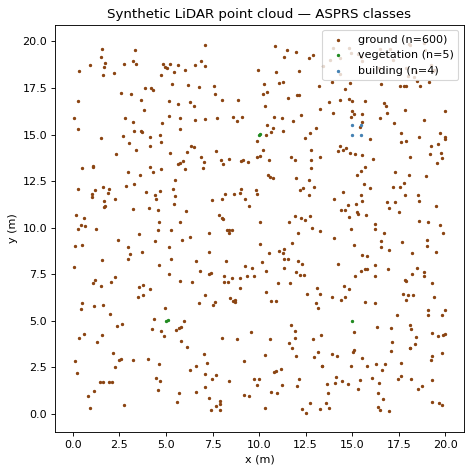

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
colours = {2: "saddlebrown", 5: "forestgreen", 6: "steelblue"}
labels = {2: "ground", 5: "vegetation", 6: "building"}
for code, col in colours.items():
 mask = cloud.classification == code
 ax.scatter(cloud.x[mask], cloud.y[mask], c=col, s=4,
 label=f"{labels[code]} (n={int(mask.sum())})")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("Synthetic LiDAR point cloud — ASPRS classes")
ax.legend(loc="upper right")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


## Ground classification (Zhang 2003)

Builds a min-grid DEM, runs a morphological opening, and marks points more than
`slope_threshold` above the opening as non-ground.

In [4]:
predicted_class = classify_ground(
 cloud, method="zhang", cell_size=1.0, window_cells=3, slope_threshold=1.0,
)
n_ground_predicted = int((predicted_class == 2).sum())
n_nonground_predicted = int((predicted_class == 1).sum())
print(f"Predicted ground: {n_ground_predicted} / {len(cloud)} points")
print(f"Predicted non-ground: {n_nonground_predicted} / {len(cloud)} points")

Predicted ground: 600 / 609 points
Predicted non-ground: 9 / 609 points


## `filter_classes` — keep only ground returns

Subset the cloud by ASPRS class code. Standard codes: 2 = ground, 5 = high vegetation,
6 = building, 9 = water.

In [5]:
# Use the predicted classification (replacing the input labels).
reclassified = LasPoints(
 x=cloud.x, y=cloud.y, z=cloud.z, classification=predicted_class,
)
ground_only = filter_classes(reclassified, {2})
print(f"Ground-only subset: {len(ground_only)} points")

Ground-only subset: 600 points


## Gridding via IDW interpolation

Inverse-distance-weighted mean of the K nearest points at each cell centre. Good general-purpose
choice that handles non-uniform sampling gracefully.

In [6]:
dtm = grid_lidar_points(
 ground_only.x, ground_only.y, ground_only.z,
 cell_size=0.5, bounds=(0.0, 0.0, 20.0, 20.0),
 aggregate="idw", epsg=3857, idw_k=8,
)
dtm_arr = dtm.read_array()
valid = dtm_arr[dtm_arr != -9999.0]
print(f"DTM shape: {dtm_arr.shape}")
print(f"DTM range: [{valid.min():.3f}, {valid.max():.3f}] m")

DTM shape: (40, 40)
DTM range: [-0.129, 0.158] m


## Visualise: DTM from IDW gridding

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
show = np.where(dtm_arr == -9999.0, np.nan, dtm_arr)
im = ax.imshow(show, cmap="terrain", origin="upper",
 extent=(0, 20, 0, 20))
ax.set_title("DTM from IDW gridding (ground points only)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig.colorbar(im, ax=ax, shrink=0.7, label="elevation (m)")
fig.tight_layout()
plt.show()


## Build a DSM via block-max

Per-cell maximum z is the canonical DSM (Digital Surface Model — top-of-canopy). Subtract DTM
from DSM to get a CHM (Canopy Height Model).

In [8]:
dsm = grid_lidar_points(
 cloud.x, cloud.y, cloud.z,
 cell_size=0.5, bounds=(0.0, 0.0, 20.0, 20.0),
 aggregate="max", epsg=3857,
)
dsm_arr = dsm.read_array()
chm_arr = np.where(
 (dsm_arr != -9999.0) & (dtm_arr != -9999.0), dsm_arr - dtm_arr, -9999.0,
).astype(np.float32)
valid_chm = chm_arr[chm_arr != -9999.0]
print(f"CHM range: [{valid_chm.min():.3f}, {valid_chm.max():.3f}] m")

CHM range: [-0.062, 8.190] m


## Tree detection on the CHM

Variable-window local-maxima with window radius scaling by canopy height
(`_default_tree_radius(h) = 0.5 + 0.05 * h`).

In [9]:
from pyramids.dataset import Dataset
chm = Dataset.create_from_array(
 chm_arr, geo=dtm.geotransform, epsg=dtm.epsg, no_data_value=-9999.0,
)
tops = detect_trees(chm, min_height_m=2.0)
print(tops[["height_m", "row", "col"]])

 height_m row col
0 3.999202 10 20
1 3.024533 10 30
2 6.515433 30 10
3 8.189700 30 30


## Visualise: CHM with detected tree tops

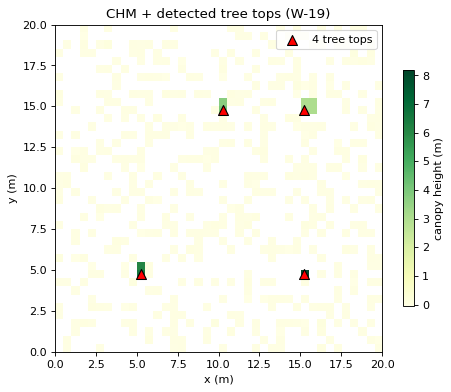

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
chm_show = np.where(chm_arr == -9999.0, np.nan, chm_arr)
im = ax.imshow(chm_show, cmap="YlGn", origin="upper",
 extent=(0, 20, 0, 20))
# Convert top row/col to world coords (extent matches the grid bounds).
top_x = (tops["col"].values + 0.5) * 0.5
top_y = 20.0 - (tops["row"].values + 0.5) * 0.5
ax.scatter(top_x, top_y, c="red", marker="^", s=80, edgecolor="black",
 label=f"{len(tops)} tree tops")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("CHM + detected tree tops")
ax.legend()
fig.colorbar(im, ax=ax, shrink=0.7, label="canopy height (m)")
fig.tight_layout()
plt.show()


## Clip + merge

Split the cloud into spatial tiles via `clip` then put it back together with `merge`.

In [11]:
west = clip(cloud, box(0, 0, 10, 20))
east = clip(cloud, box(10, 0, 20, 20))
stitched = merge(west, east)
print(f"Original: {len(cloud)} points")
print(f"West tile: {len(west)} points")
print(f"East tile: {len(east)} points")
print(f"Stitched: {len(stitched)} points")

Original: 609 points
West tile: 275 points
East tile: 333 points
Stitched: 608 points


## Summary

From a 609-point synthetic cloud we built a DTM via IDW interpolation, a DSM via block-max, a
CHM by subtraction, and a tree-top GeoDataFrame from the CHM — covering (the LasPoints
record), (Zhang ground filter), (interpolation gridders), (clip/merge/filter), and
 (tree detection).